In [4]:
import pandas as pd

In [6]:
driver_species_20 = pd.read_csv('driver_species_20')

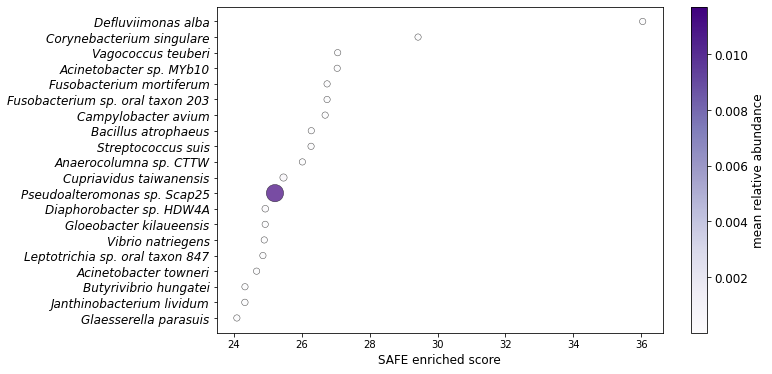

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

df_small = driver_species_20

# Create the dot plot
plt.figure(figsize=(10, 6))

# Normalize the size values to match the desired abundance range
norm = mcolors.Normalize(vmin=driver_species_20['mean_relative_abundance'].min(), 
                         vmax=driver_species_20['mean_relative_abundance'].max())

scatter = sns.scatterplot(
    data=df_small,
    y=df_small.index,  # Microbes on y-axis
    x="SAFE enriched score",  # Score on x-axis
    size="mean_relative_abundance",  # Dot size based on mean abundance
    sizes=(40, 300),  # Adjust dot size range
    alpha=0.7,
    hue="mean_relative_abundance",  # Color the dots by abundance (optional)
    palette="Purples",  # Optional: change palette
    edgecolor="black",  # Circle borders are black
    linewidth=0.5,  # Set the thickness of the border
    legend=None,  # Disable automatic legend
)

# Manually create a color bar for abundance
sm = plt.cm.ScalarMappable(cmap="Purples", norm=norm)
sm.set_array([])  # Set an empty array, required by ScalarMappable
cbar = plt.colorbar(sm)
cbar.set_label("mean relative abundance", size=12)
cbar.ax.tick_params(labelsize=12)

# Improve readability
plt.xticks()  # Rotate x-axis labels for better visibility
plt.xlabel("SAFE enriched score", size=12)
plt.ylabel("")
plt.gca().tick_params(axis='y', labelsize=12)  # Optional: Change font size if needed
plt.gca().yaxis.set_tick_params(labelrotation=0)
for label in plt.gca().get_yticklabels():
    label.set_fontstyle('italic')

# Optional: Title for the plot
# plt.title("Driver species in lung cancer MG")

# Save the figure
plt.savefig('Driver_species_MG_SC_BAL_0405_new_clr.pdf', bbox_inches='tight')

In [77]:
filtered_df = edges_df_with_relative_abundance[edges_df_with_relative_abundance['start'].isin(driver_species_20.index)]

In [8]:
edges_df_with_relative_abundance = pd.read_csv('edges_df_with_relative_abundance.csv')

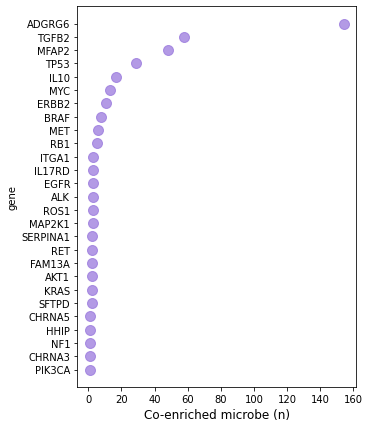

In [81]:
import matplotlib.pyplot as plt

df = edges_df_with_relative_abundance
value_counts = df.iloc[:, 1].value_counts()

sorted_counts = value_counts.sort_values(ascending=True)  

plt.figure(figsize=(5, 7))
plt.scatter(sorted_counts.values, sorted_counts.index, color="mediumpurple", s=100, alpha=0.7)
plt.xlabel("Co-enriched microbe (n)", size=12)
plt.ylabel("gene")
plt.title("")
plt.xticks()
plt.grid(axis="y", linestyle="", alpha=0.6)

# Show plot
plt.savefig('MG_coenriched_microbe_n_forgenes_SC_new_clr.pdf',bbox_inches='tight')